# GNN: Rank Loss Models

Trains three GNN variants (Correlation, Sector, Granger) using a pairwise BPR rank loss
instead of MSE. The rank loss directly optimizes cross-sectional ordering of predicted RV,
which is what the inverse-vol and long-short portfolios reward.

These models are **separate** from the MSE-trained models in `04_gnn_models.ipynb`.
Checkpoints use `_rankloss` suffixes and test predictions are saved to separate parquet files.
Both model families can be evaluated side-by-side in `05_evaluate.ipynb`.

Architecture is identical to the MSE models:
- **Correlation**: GNNModelV2 with hparam-tuned config (if available), else GNNModel
- **Sector**: GNNModel
- **Granger**: GNNModel

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import json
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import config
from src.models import GNNModel, compute_har_features
from src.train import (
    set_seeds,
    compute_rank_loss,
    train_gnn_corr_rankloss,
    train_gnn_sector_rankloss,
    train_gnn_granger_rankloss,
)
from src.graphs import (
    build_all_sector_graphs,
    build_granger_graph,
    precompute_corr_graphs,
    load_corr_graphs,
)
from src.train import predict_gnn_split

In [2]:
# Load all data
target    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'target.parquet')
splits    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'splits.parquet')
tickers   = target.columns.tolist()

meta          = json.load(open(Path(config.DATA_FEATURES_DIR) / 'features_meta.json'))
feature_names = meta['feature_names']
feat_df       = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'features.parquet')
feat_df['week'] = pd.to_datetime(feat_df['week'])
feat_df = feat_df[feat_df['week'].isin(target.index)].copy()
ticker_order    = {t: i for i, t in enumerate(tickers)}
feat_df['_ord'] = feat_df['ticker'].map(ticker_order)
feat_df = feat_df.sort_values(['week', '_ord']).drop(columns='_ord')

n_weeks  = target.shape[0]
n_stocks = target.shape[1]
n_feats  = len(feature_names)

features_3d = feat_df[feature_names].values.reshape(n_weeks, n_stocks, n_feats)
target_arr  = target.values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

assert features_3d.shape == (n_weeks, n_stocks, n_feats)
assert target_arr.shape  == (n_weeks, n_stocks)
print(f'features_3d: {features_3d.shape}  target_arr: {target_arr.shape}')
print(f'tickers: {len(tickers)}  n_feats: {n_feats}  device: {device}')

features_3d: (572, 465, 10)  target_arr: (572, 465)
tickers: 465  n_feats: 10  device: cuda


In [3]:
log_returns    = pd.read_parquet(Path(config.DATA_RAW_DIR) / 'log_returns.parquet')
sector_history = json.load(open(Path(config.DATA_RAW_DIR) / 'sector_history.json'))
granger_df     = pd.read_parquet(Path(config.DATA_GRAPHS_DIR) / 'granger_edges.parquet')

granger_edge_index = torch.tensor(
    granger_df[['src', 'dst']].values.T, dtype=torch.long
)

# Pre-build sector graphs for all years
sector_graphs_dict = build_all_sector_graphs(
    tickers=tickers,
    sector_history=sector_history,
    years=range(2015, 2026),
)

# Correlation graphs — already precomputed by 04_gnn_models.ipynb, skips if exists
precompute_corr_graphs(log_returns=log_returns, splits=splits)

ablation_data = json.load(open(Path(config.DATA_RESULTS_DIR) / 'corr_threshold_ablation.json'))
best_theta    = ablation_data['best_threshold']

# Load train+val corr graphs for the winning threshold
corr_graphs = {
    **load_corr_graphs(best_theta, 'train'),
    **load_corr_graphs(best_theta, 'val'),
}

print(f'Granger edges:   {granger_edge_index.shape[1]:,}')
print(f'Corr threshold:  θ={best_theta}')
print(f'Corr graphs loaded: {len(corr_graphs)} weeks')

Saved 269890 total edges across 11 years to C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\sector_edges_by_year.parquet
  train/t0p3: already exists, skipping
  train/t0p5: already exists, skipping
  train/t0p7: already exists, skipping
  val/t0p3: already exists, skipping
  val/t0p5: already exists, skipping
  val/t0p7: already exists, skipping
  test/t0p3: already exists, skipping
  test/t0p5: already exists, skipping
  test/t0p7: already exists, skipping
precompute_corr_graphs: done.
Granger edges:   13,886
Corr threshold:  θ=0.3
Corr graphs loaded: 469 weeks


## Rank Loss Sanity Check

Verify that `compute_rank_loss` returns a differentiable scalar on one sample step.
The loss should be positive and have a grad_fn (so gradients flow through it).

In [4]:
sample_pos  = 200
sample_week = target.index[sample_pos]

set_seeds()
_test_model = GNNModel(in_channels=n_feats).to(device)
x_t = torch.tensor(features_3d[sample_pos], dtype=torch.float32).to(device)
y_t = torch.tensor(target_arr[sample_pos],   dtype=torch.float32).to(device)

# Use a static sector graph for this check (no dynamic recomputation)
ei_t  = sector_graphs_dict[sample_week.year].to(device)
preds = _test_model(x_t, ei_t)

rank_loss_val = compute_rank_loss(preds, y_t)
mse_loss_val  = torch.nn.functional.mse_loss(
    preds[~y_t.isnan()], y_t[~y_t.isnan()]
)

print(f'Week: {sample_week.date()}')
print(f'Rank loss : {rank_loss_val.item():.6f}  grad_fn={rank_loss_val.grad_fn}')
print(f'MSE loss  : {mse_loss_val.item():.6f}  grad_fn={mse_loss_val.grad_fn}')

assert rank_loss_val.grad_fn is not None, 'Rank loss has no grad_fn — cannot backprop'
assert mse_loss_val.grad_fn  is not None, 'MSE loss has no grad_fn'

# Verify gradients flow through rank loss
rank_loss_val.backward()
max_grad = max(p.grad.abs().max().item() for p in _test_model.parameters() if p.grad is not None)
print(f'Max gradient magnitude after rank loss backward: {max_grad:.6f}')
assert max_grad > 0, 'Zero gradients — rank loss is not training the model'
print('Sanity check passed.')
del _test_model

C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:289: UserWarning: GNNModel.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Week: 2018-11-05
Rank loss : 0.677065  grad_fn=<MeanBackward0 object at 0x000001E4EA123B20>
MSE loss  : 0.135838  grad_fn=<MseLossBackward0 object at 0x000001E4A8A73790>
Max gradient magnitude after rank loss backward: 0.087471
Sanity check passed.


## GNN-Correlation — Rank Loss

Trains using the best correlation threshold (θ=ablation winner) and the hparam-tuned
GNNModelV2 architecture. Skips training if the checkpoint already exists.

In [5]:
_ckpt_path = Path(config.CHECKPOINTS_DIR) / 'gnn_corr_rankloss_best.pt'

if _ckpt_path.exists():
    print('gnn_corr_rankloss_best.pt found — skipping training.')
    _loss_data = json.load(open(Path(config.DATA_RESULTS_DIR) / 'gnn_corr_rankloss_val_loss.json'))
    corr_rl_val_loss = _loss_data['val_loss']
    print(f'Best val rank loss: {_loss_data["best_val_loss"]:.6f}')
else:
    _, corr_rl_val_loss = train_gnn_corr_rankloss(
        features=features_3d,
        target=target_arr,
        week_index=target.index,
        corr_graphs=corr_graphs,
        splits=splits,
        device=device,
    )
    print(f'Training complete. Checkpoint: gnn_corr_rankloss_best.pt')

c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Epoch   1  train=0.617891  val=0.621748
Epoch   2  train=0.613863  val=0.620760
Epoch   3  train=0.612756  val=0.620187
Epoch   4  train=0.611875  val=0.619731
Epoch   5  train=0.611408  val=0.619819
Epoch   6  train=0.610355  val=0.620232
Epoch   7  train=0.610157  val=0.620073
Epoch   8  train=0.609776  val=0.618083
Epoch   9  train=0.609527  val=0.619281
Epoch  10  train=0.608966  val=0.619415
Epoch  11  train=0.608720  val=0.618965
Epoch  12  train=0.608401  val=0.618380
Epoch  13  train=0.608267  val=0.618774
Epoch  14  train=0.608220  val=0.618295
Epoch  15  train=0.607460  val=0.618710
Epoch  16  train=0.606770  val=0.618119
Epoch  17  train=0.606332  val=0.619088
Epoch  18  train=0.606293  val=0.617985
Epoch  19  train=0.606548  val=0.618475
Epoch  20  train=0.605863  val=0.617955
Epoch  21  train=0.605982  val=0.617608
Epoch  22  train=0.605949  val=0.618750
Epoch  23  train=0.605791  val=0.618007
Epoch  24  train=0.605589  val=0.617954
Epoch  25  train=0.605157  val=0.618264


## GNN-Sector — Rank Loss

In [6]:
_ckpt_path = Path(config.CHECKPOINTS_DIR) / 'gnn_sector_rankloss_best.pt'

if _ckpt_path.exists():
    print('gnn_sector_rankloss_best.pt found — skipping training.')
    _loss_data = json.load(open(Path(config.DATA_RESULTS_DIR) / 'gnn_sector_rankloss_val_loss.json'))
    sector_rl_val_loss = _loss_data['val_loss']
    print(f'Best val rank loss: {_loss_data["best_val_loss"]:.6f}')
else:
    _, sector_rl_val_loss = train_gnn_sector_rankloss(
        features=features_3d,
        target=target_arr,
        week_index=target.index,
        sector_graphs=sector_graphs_dict,
        splits=splits,
        device=device,
    )
    print(f'Training complete. Checkpoint: gnn_sector_rankloss_best.pt')

Epoch   1  train=0.619057  val=0.624439
Epoch   2  train=0.614070  val=0.622315
Epoch   3  train=0.612940  val=0.620970
Epoch   4  train=0.612218  val=0.621458
Epoch   5  train=0.611812  val=0.621124
Epoch   6  train=0.611463  val=0.620846
Epoch   7  train=0.611034  val=0.621350
Epoch   8  train=0.610930  val=0.620748
Epoch   9  train=0.610471  val=0.620011
Epoch  10  train=0.610221  val=0.621297
Epoch  11  train=0.610237  val=0.620655
Epoch  12  train=0.609813  val=0.620228
Epoch  13  train=0.609760  val=0.620938
Epoch  14  train=0.609198  val=0.622103
Epoch  15  train=0.609217  val=0.622330
Epoch  16  train=0.608187  val=0.619752
Epoch  17  train=0.607804  val=0.620729
Epoch  18  train=0.608173  val=0.620352
Epoch  19  train=0.607733  val=0.620279
Epoch  20  train=0.607351  val=0.621948
Epoch  21  train=0.607433  val=0.621314
Epoch  22  train=0.607369  val=0.620483
Epoch  23  train=0.606351  val=0.621732
Epoch  24  train=0.606218  val=0.622959
Epoch  25  train=0.606335  val=0.620421


## GNN-Granger — Rank Loss

In [7]:
_ckpt_path = Path(config.CHECKPOINTS_DIR) / 'gnn_granger_rankloss_best.pt'

if _ckpt_path.exists():
    print('gnn_granger_rankloss_best.pt found — skipping training.')
    _loss_data = json.load(open(Path(config.DATA_RESULTS_DIR) / 'gnn_granger_rankloss_val_loss.json'))
    granger_rl_val_loss = _loss_data['val_loss']
    print(f'Best val rank loss: {_loss_data["best_val_loss"]:.6f}')
else:
    _, granger_rl_val_loss = train_gnn_granger_rankloss(
        features=features_3d,
        target=target_arr,
        week_index=target.index,
        granger_edge_index=granger_edge_index,
        splits=splits,
        device=device,
    )
    print(f'Training complete. Checkpoint: gnn_granger_rankloss_best.pt')

Epoch   1  train=0.619834  val=0.623292
Epoch   2  train=0.614744  val=0.621359
Epoch   3  train=0.613525  val=0.620328
Epoch   4  train=0.612748  val=0.620447
Epoch   5  train=0.611987  val=0.619973
Epoch   6  train=0.611456  val=0.619517
Epoch   7  train=0.611022  val=0.620316
Epoch   8  train=0.610961  val=0.619757
Epoch   9  train=0.610493  val=0.619204
Epoch  10  train=0.610266  val=0.619972
Epoch  11  train=0.610265  val=0.619963
Epoch  12  train=0.609840  val=0.619669
Epoch  13  train=0.609685  val=0.619892
Epoch  14  train=0.609176  val=0.620845
Epoch  15  train=0.609235  val=0.620785
Epoch  16  train=0.608112  val=0.619231
Epoch  17  train=0.607887  val=0.620027
Epoch  18  train=0.608434  val=0.619648
Epoch  19  train=0.607846  val=0.619977
Early stop at epoch 19 (no improvement for 10 epochs)
Training complete. Checkpoint: gnn_granger_rankloss_best.pt


## Test Predictions

Generate test-set predictions for all three rank-loss models and save to parquet.
Saved as `test_preds_gnn_{variant}_rankloss.parquet` — separate from the MSE model parquets.

In [8]:
from src.evaluate import _load_gnn_model
from src.models import GNNModelV2

results_dir = Path(config.DATA_RESULTS_DIR)
ckpt_dir    = Path(config.CHECKPOINTS_DIR)
test_corr_graphs = load_corr_graphs(best_theta, 'test')

# GNN-Correlation rank loss — use GNNModelV2 if hparam config exists
hparam_json = results_dir / 'gnn_hparam_search_results.json'
if hparam_json.exists():
    hparam_cfg = json.load(open(hparam_json))['best_config']
    corr_rl_model = GNNModelV2(
        in_channels=n_feats,
        hidden_dim=int(hparam_cfg['hidden_dim']),
        dropout=float(hparam_cfg['dropout']),
        num_layers=int(hparam_cfg['num_layers']),
        batch_norm=bool(hparam_cfg['batch_norm']),
    ).to(device)
    corr_rl_model.load_state_dict(
        torch.load(ckpt_dir / 'gnn_corr_rankloss_best.pt', map_location=device, weights_only=True)
    )
else:
    corr_rl_model = _load_gnn_model(ckpt_dir / 'gnn_corr_rankloss_best.pt', n_feats, device)

sector_rl_model  = _load_gnn_model(ckpt_dir / 'gnn_sector_rankloss_best.pt',  n_feats, device)
granger_rl_model = _load_gnn_model(ckpt_dir / 'gnn_granger_rankloss_best.pt', n_feats, device)

model_configs = [
    ('gnn_corr_rankloss',    corr_rl_model,    lambda w, g=test_corr_graphs: g.get(w, torch.zeros(2, 0, dtype=torch.long))),
    ('gnn_sector_rankloss',  sector_rl_model,  lambda w: sector_graphs_dict[w.year]),
    ('gnn_granger_rankloss', granger_rl_model, lambda w: granger_edge_index),
]

for key, model, edge_fn in model_configs:
    preds_df = predict_gnn_split(
        model=model,
        features=features_3d,
        week_index=target.index,
        edge_index_fn=edge_fn,
        splits=splits,
        tickers=tickers,
        device=device,
        split_name='test',
    )
    out_path = results_dir / f'test_preds_{key}.parquet'
    preds_df.to_parquet(out_path)
    print(f'{key}: shape={preds_df.shape}  saved -> {out_path.name}')

C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


gnn_corr_rankloss: shape=(103, 465)  saved -> test_preds_gnn_corr_rankloss.parquet


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:289: UserWarning: GNNModel.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


gnn_sector_rankloss: shape=(103, 465)  saved -> test_preds_gnn_sector_rankloss.parquet
gnn_granger_rankloss: shape=(103, 465)  saved -> test_preds_gnn_granger_rankloss.parquet


## Experiment registry reference

Current training and evaluation artifacts should be registered before downstream comparison.

In [1]:
# REGISTRY_REFERENCE_CELL
from pathlib import Path
import pandas as pd
from IPython.display import display

registry_path = Path('../data/results/experiment_registry.csv')
registry = pd.read_csv(registry_path)
display(registry[['experiment_id', 'model_name', 'feature_version', 'graph_version', 'checkpoint_path']])
print(f'Registry path: {registry_path.as_posix()}')


experiment_id,model_name,feature_version,graph_version,checkpoint_path
baseline_har_per_stock,HAR per-stock,har_realized_volatility_lags_v1,none,NaN
baseline_har_pooled,HAR pooled,har_realized_volatility_lags_v1,none,NaN
baseline_lstm,LSTM,stock_features_v1,none,data/results/checkpoints/lstm_best.pt
baseline_gnn_correlation,GNN-Correlation,stock_features_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_best.pt
baseline_gnn_sector,GNN-Sector,stock_features_v1,sector_yfinance_labels_v1,data/results/checkpoints/gnn_sector_best.pt
baseline_gnn_granger,GNN-Granger,stock_features_v1,granger_lag_5_bonferroni,data/results/checkpoints/gnn_granger_best.pt
baseline_gnn_ensemble,GNN-Ensemble,stock_features_v1,correlation+sector+granger_v1,NaN
rankloss_gnn_correlation,Rank-loss GNN-Correlation,stock_features_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_rankloss_best.pt
rankloss_gnn_sector,Rank-loss GNN-Sector,stock_features_v1,sector_yfinance_labels_v1,data/results/checkpoints/gnn_sector_rankloss_best.pt
rankloss_gnn_granger,Rank-loss GNN-Granger,stock_features_v1,granger_lag_5_bonferroni,data/results/checkpoints/gnn_granger_rankloss_best.pt


Registry path: ../data/results/experiment_registry.csv


## Val MSE Comparison: MSE Loss vs Rank Loss

Compute val-set MSE for the rank-loss models so they can be compared to the MSE-trained
models on the same scale. Val rank loss values are not directly comparable to MSE.

In [9]:
from src.evaluate import compute_metrics

val_weeks  = sorted(splits.loc[splits['split'] == 'val', 'week'])
target_df  = pd.DataFrame(target_arr, index=target.index, columns=tickers)
target_val = target_df.loc[target_df.index.isin(val_weeks)]

val_corr_graphs = load_corr_graphs(best_theta, 'val')

rl_model_configs = [
    ('GNN-Correlation (rank loss)', corr_rl_model,    lambda w, g=val_corr_graphs: g.get(w, torch.zeros(2, 0, dtype=torch.long))),
    ('GNN-Sector (rank loss)',      sector_rl_model,  lambda w: sector_graphs_dict[w.year]),
    ('GNN-Granger (rank loss)',     granger_rl_model, lambda w: granger_edge_index),
]

rl_val_mse: dict[str, float] = {}
for label, model, edge_fn in rl_model_configs:
    preds_val = predict_gnn_split(
        model=model,
        features=features_3d,
        week_index=target.index,
        edge_index_fn=edge_fn,
        splits=splits,
        tickers=tickers,
        device=device,
        split_name='val',
    ).reindex(target_val.index)
    m = compute_metrics(target_val.values, preds_val.values)
    rl_val_mse[label] = m['mse']

# Load MSE model val losses for comparison
mse_val_mse = {
    f'GNN-Correlation (θ={best_theta}, MSE)': ablation_data['best_val_mse'],
    'GNN-Sector (MSE)':  json.load(open(results_dir / 'gnn_sector_val_loss.json'))['best_val_loss'],
    'GNN-Granger (MSE)': json.load(open(results_dir / 'gnn_granger_val_loss.json'))['best_val_loss'],
}

print(f'{"Model":<42}  {"Val MSE":>10}')
print('-' * 56)
for label, mse in mse_val_mse.items():
    print(f'{label:<42}  {mse:>10.6f}')
print()
for label, mse in rl_val_mse.items():
    print(f'{label:<42}  {mse:>10.6f}')

C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:289: UserWarning: GNNModel.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Model                                          Val MSE
--------------------------------------------------------
GNN-Correlation (θ=0.3, MSE)                  0.019778
GNN-Sector (MSE)                              0.022894
GNN-Granger (MSE)                             0.022615

GNN-Correlation (rank loss)                   0.190358
GNN-Sector (rank loss)                        0.178683
GNN-Granger (rank loss)                       0.134868


## Val Loss Curves

Rank loss values are not on the same scale as MSE, so the two sets of curves are
plotted separately. Both should show convergence over epochs.

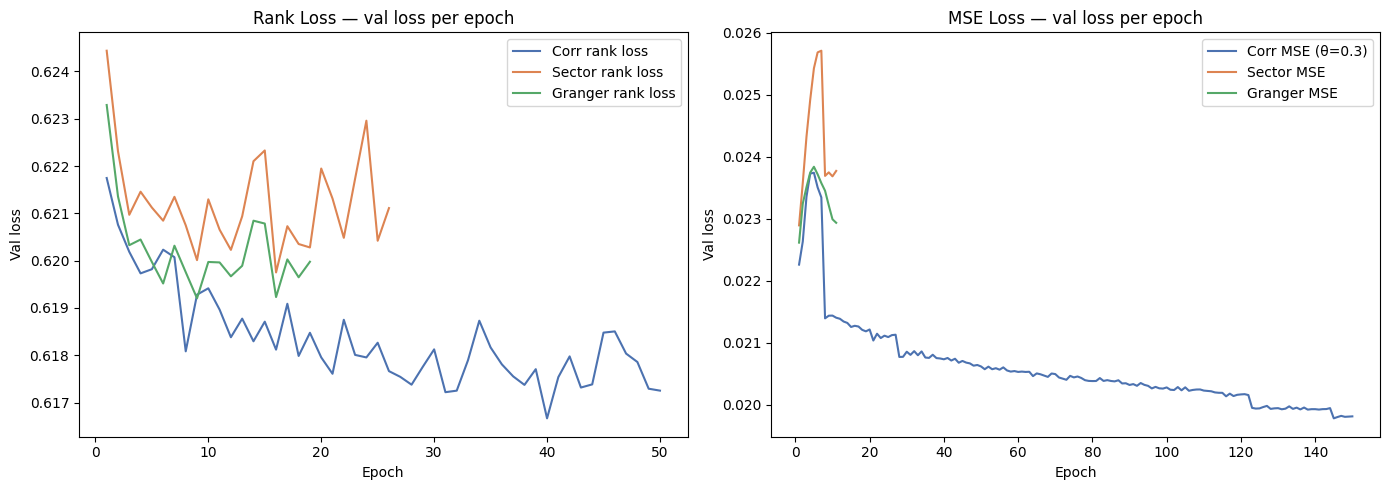

In [10]:
import matplotlib.pyplot as plt

rl_curves = {
    'Corr rank loss':    json.load(open(results_dir / 'gnn_corr_rankloss_val_loss.json'))['val_loss'],
    'Sector rank loss':  json.load(open(results_dir / 'gnn_sector_rankloss_val_loss.json'))['val_loss'],
    'Granger rank loss': json.load(open(results_dir / 'gnn_granger_rankloss_val_loss.json'))['val_loss'],
}
mse_curves = {
    f'Corr MSE (θ={best_theta})': json.load(open(results_dir / f'gnn_corr_th{int(best_theta*10):02d}_val_loss.json'))['val_loss'],
    'Sector MSE':                 json.load(open(results_dir / 'gnn_sector_val_loss.json'))['val_loss'],
    'Granger MSE':                json.load(open(results_dir / 'gnn_granger_val_loss.json'))['val_loss'],
}
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, curves, title in [
    (axes[0], rl_curves,  'Rank Loss — val loss per epoch'),
    (axes[1], mse_curves, 'MSE Loss — val loss per epoch'),
]:
    for (label, values), color in zip(curves.items(), colors):
        ax.plot(range(1, len(values) + 1), values, label=label, color=color, linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val loss')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## Ranking Evaluation Metrics

Computes Rank IC, ICIR, IC t-stat/p-value, top-25% hit rate, and pairwise accuracy
on the **test set** for all six GNN variants (three MSE-trained, three rank-loss-trained).

- **Rank IC**: Spearman correlation between predicted and actual RV, cross-sectionally each week.
- **ICIR**: IC / std(IC) — measures consistency of the signal, not just average level.
- **Top-25% Hit Rate**: fraction of actual top-quartile high-vol stocks correctly identified in the predicted top quartile. Random baseline = 0.25.
- **Pairwise Accuracy**: fraction of stock pairs correctly ordered by predicted RV. Random baseline = 0.50.

The key comparison is MSE loss vs rank loss for each graph type. Rank loss directly
optimizes pairwise accuracy, so it should improve that metric. Whether Rank IC and
hit rate also improve tells us if the ranking improvement generalizes.

In [11]:
from src.evaluate import compute_all_ranking_metrics, RankingEvalResult

# Test-period target (actual RV for week T+1, stored at row T)
test_weeks  = sorted(splits.loc[splits['split'] == 'test', 'week'])
target_test = target_df.reindex(test_weeks)

# Load MSE model test predictions (saved by 05_evaluate.ipynb or run_test_evaluation)
mse_pred_keys = {
    f'GNN-Corr (θ={best_theta}, MSE)': 'gnn_corr',
    'GNN-Sector (MSE)':                'gnn_sector',
    'GNN-Granger (MSE)':               'gnn_granger',
}
rl_pred_keys = {
    'GNN-Corr (rank loss)':    'gnn_corr_rankloss',
    'GNN-Sector (rank loss)':  'gnn_sector_rankloss',
    'GNN-Granger (rank loss)': 'gnn_granger_rankloss',
}

all_pred_keys = {**mse_pred_keys, **rl_pred_keys}
results: list[RankingEvalResult] = []

for label, key in all_pred_keys.items():
    path = results_dir / f'test_preds_{key}.parquet'
    if not path.exists():
        print(f'  Skipping {label} — {path.name} not found')
        continue
    preds_test = pd.read_parquet(path).reindex(target_test.index)
    r = compute_all_ranking_metrics(preds_test, target_test, model_name=label)
    results.append(r)
    print(f'  {label}: IC={r.mean_ic:.4f}  ICIR={r.icir:.3f}  hit={r.mean_hit_rate:.3f}  pair={r.mean_pairwise_acc:.3f}')

# Summary table
summary_rows = [
    {
        'Model':           r.model_name,
        'Mean IC':         round(r.mean_ic,         4),
        'ICIR':            round(r.icir,             3),
        'IC t-stat':       round(r.ic_tstat,         2),
        'IC p-value':      round(r.ic_pvalue,        4),
        '% IC > 0':        round(r.pct_positive_ic,  3),
        'Hit Rate (25%)':  round(r.mean_hit_rate,    3),
        'Pairwise Acc':    round(r.mean_pairwise_acc, 3),
    }
    for r in results
]
summary_df = pd.DataFrame(summary_rows).set_index('Model')
print()
print(summary_df.to_string())

  GNN-Corr (θ=0.3, MSE): IC=0.4165  ICIR=3.440  hit=0.492  pair=0.645
  GNN-Sector (MSE): IC=0.3826  ICIR=3.399  hit=0.479  pair=0.633
  GNN-Granger (MSE): IC=0.3749  ICIR=3.663  hit=0.473  pair=0.629
  GNN-Corr (rank loss): IC=0.4293  ICIR=3.863  hit=0.510  pair=0.499
  GNN-Sector (rank loss): IC=0.4203  ICIR=4.123  hit=0.506  pair=0.500
  GNN-Granger (rank loss): IC=0.4139  ICIR=4.326  hit=0.506  pair=0.436

                         Mean IC   ICIR  IC t-stat  IC p-value  % IC > 0  Hit Rate (25%)  Pairwise Acc
Model                                                                                                 
GNN-Corr (θ=0.3, MSE)     0.4165  3.440      34.91         0.0       1.0           0.492         0.645
GNN-Sector (MSE)          0.3826  3.399      34.50         0.0       1.0           0.479         0.633
GNN-Granger (MSE)         0.3749  3.663      37.18         0.0       1.0           0.473         0.629
GNN-Corr (rank loss)      0.4293  3.863      39.20         0.0       1.

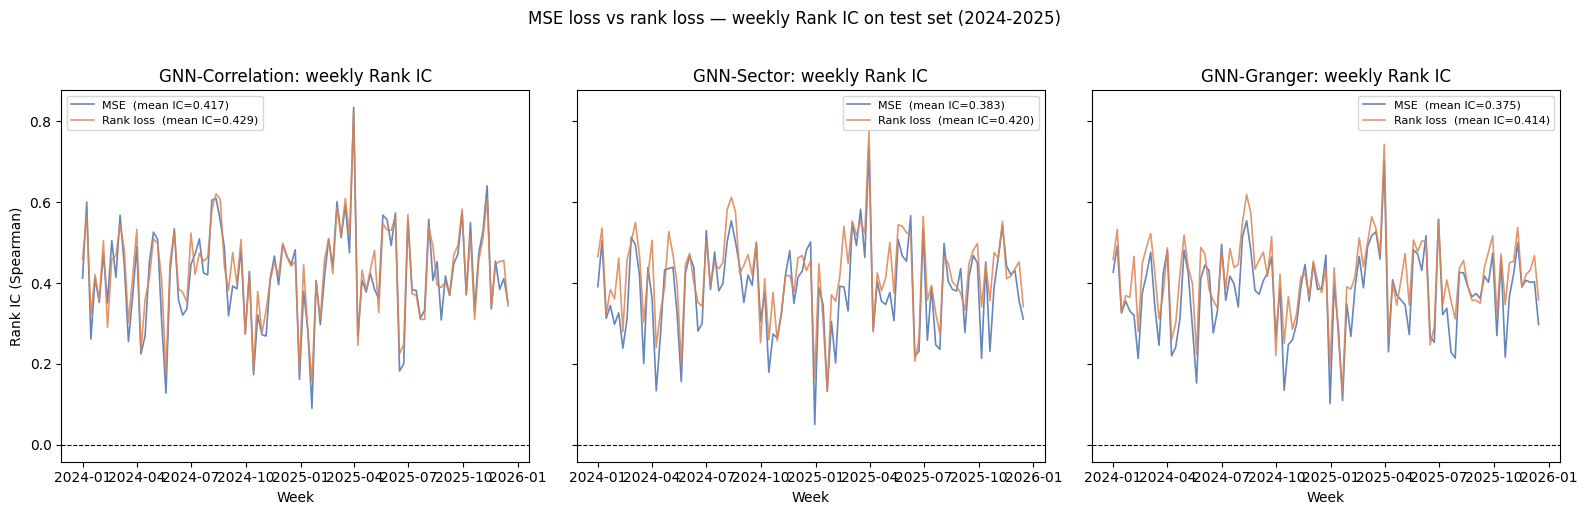

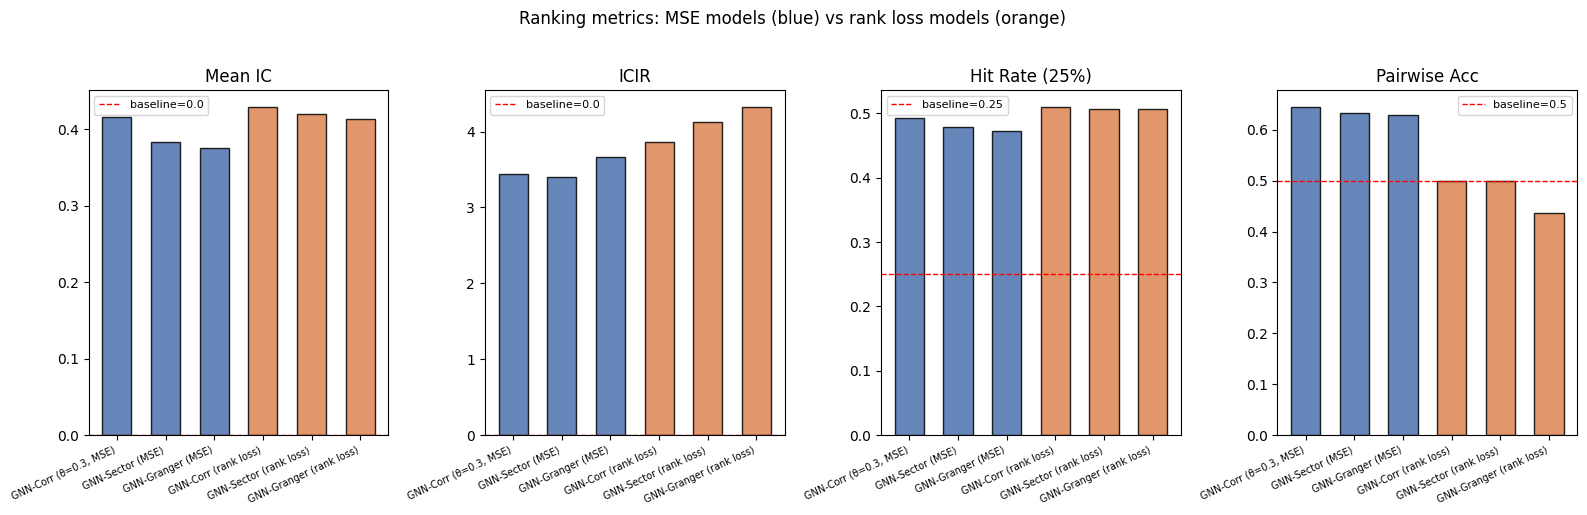

In [ ]:
import matplotlib.pyplot as plt

# Pair up MSE vs rank loss results by graph type for direct comparison
graph_types = [
    ('Correlation', f'GNN-Corr (θ={best_theta}, MSE)', 'GNN-Corr (rank loss)'),
    ('Sector',      'GNN-Sector (MSE)',                 'GNN-Sector (rank loss)'),
    ('Granger',     'GNN-Granger (MSE)',                'GNN-Granger (rank loss)'),
]
results_by_name = {r.model_name: r for r in results}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (graph, mse_label, rl_label) in zip(axes, graph_types):
    mse_r = results_by_name.get(mse_label)
    rl_r  = results_by_name.get(rl_label)

    if mse_r is not None:
        ax.plot(mse_r.ic_series.index, mse_r.ic_series.values,
                color='#4C72B0', linewidth=1.2, alpha=0.85,
                label=f'MSE  (mean IC={mse_r.mean_ic:.3f})')
    if rl_r is not None:
        ax.plot(rl_r.ic_series.index, rl_r.ic_series.values,
                color='#DD8452', linewidth=1.2, alpha=0.85,
                label=f'Rank loss  (mean IC={rl_r.mean_ic:.3f})')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'GNN-{graph}: weekly Rank IC')
    ax.set_xlabel('Week')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Rank IC (Spearman)')
plt.suptitle('MSE loss vs rank loss — weekly Rank IC on test set (2024-2025)', y=1.02)
plt.tight_layout()
plt.show()

# Bar chart: key scalar metrics side by side for all 6 models
metric_cols  = ['Mean IC', 'ICIR', 'Hit Rate (25%)', 'Pairwise Acc']
baselines    = [0.0, 0.0, config.TOP_K_HIT_RATE_Q, 0.5]
n_metrics    = len(metric_cols)
n_models     = len(summary_df)
x            = np.arange(n_models)
width        = 0.18
bar_colors   = ['#4C72B0', '#4C72B0', '#4C72B0', '#DD8452', '#DD8452', '#DD8452']

fig, axes = plt.subplots(1, n_metrics, figsize=(16, 5))
for ax, col, baseline in zip(axes, metric_cols, baselines):
    vals = summary_df[col].values
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='k', alpha=0.85, width=0.6)
    ax.axhline(baseline, color='red', linestyle='--', linewidth=1.0, label=f'baseline={baseline}')
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df.index, rotation=25, ha='right', fontsize=7)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Ranking metrics: MSE models (blue) vs rank loss models (orange)', y=1.02)
plt.tight_layout()
plt.show()